In [1]:
# Import core libraries and dependencies
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from random import uniform
from mpl_toolkits.mplot3d.axes3d import Axes3D
from matplotlib import cm
from cycler import cycler

print("All libraries imported successfully!")


All libraries imported successfully!


## Example 1: The MATLAB-style API (Section 11.2.1)
The simple MATLAB-style procedural interface (`plt.plot`), suitable for introductory and quick plotting tasks.

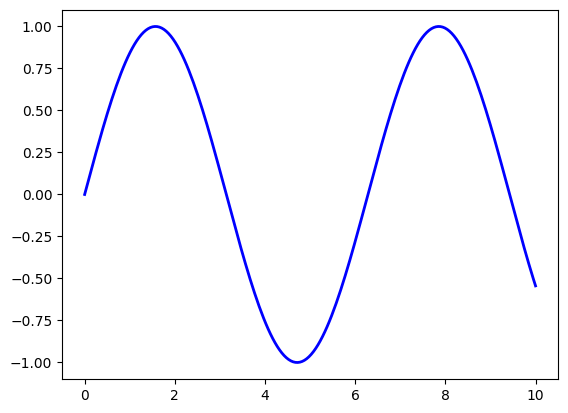

In [2]:
# Generate sample data points
x = np.linspace(0, 10, 200)
y = np.sin(x)

# Plot using MATLAB-style API
plt.figure()
plt.plot(x, y, 'b-', linewidth=2)
plt.show()


## Example 2: The Object-Oriented API (Section 11.2.2)
The explicit, object-oriented API using `fig, ax = plt.subplots()` provides greater control over figure and axes objects.

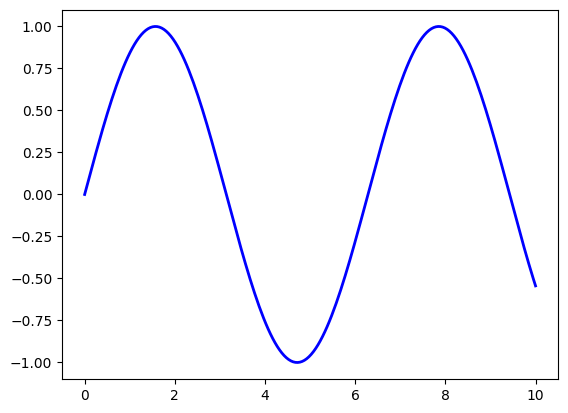

In [3]:
# Generate sample data points
x = np.linspace(0, 10, 200)
y = np.sin(x)

# Create figure and axes objects via OO API
fig, ax = plt.subplots()
ax.plot(x, y, 'b-', linewidth=2)
plt.show()


## Example 3: Tweaks - Line Color, Linewidth, Legend, and Alpha (Section 11.2.3)
Modifying the line to red (`'r-'`), setting line width, adding a label for the legend, and applying transparency with `alpha=0.6`.

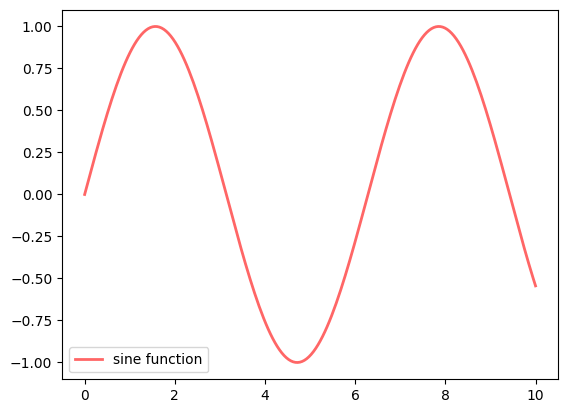

In [4]:
x = np.linspace(0, 10, 200)
y = np.sin(x)

# Plot with custom color, transparency, and legend
fig, ax = plt.subplots()
ax.plot(x, y, 'r-', linewidth=2, label='sine function', alpha=0.6)
ax.legend()
plt.show()


## Example 4: Tweaks - Changing Legend Location (Section 11.2.3)
Specifying the location of the legend explicitly using `loc='upper center'`.

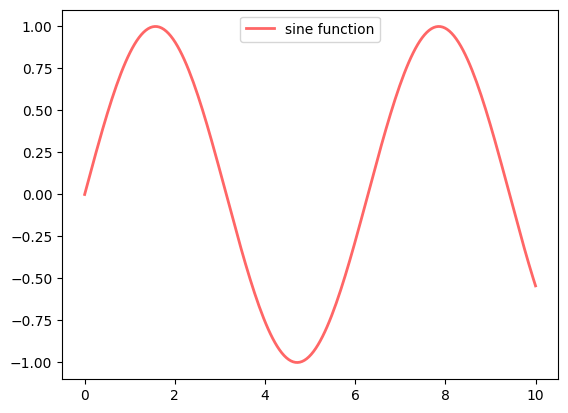

In [5]:
x = np.linspace(0, 10, 200)
y = np.sin(x)

# Adjust legend location to upper center
fig, ax = plt.subplots()
ax.plot(x, y, 'r-', linewidth=2, label='sine function', alpha=0.6)
ax.legend(loc='upper center')
plt.show()


## Example 5: Tweaks - Adding LaTeX in Labels (Section 11.2.3)
Using raw string notation `r'$y=\sin(x)$'` to render mathematical formulas in LaTeX format within legend labels.

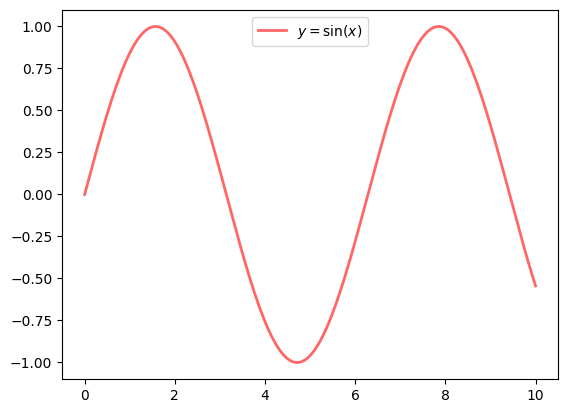

In [6]:
x = np.linspace(0, 10, 200)
y = np.sin(x)

# Add LaTeX mathematical expression in label
fig, ax = plt.subplots()
ax.plot(x, y, 'r-', linewidth=2, label=r'$y=\sin(x)$', alpha=0.6)
ax.legend(loc='upper center')
plt.show()


## Example 6: Tweaks - Controlling Ticks and Adding Title (Section 11.2.3)
Controlling tick marks using `ax.set_yticks([-1, 0, 1])` and adding a title with `ax.set_title('Test plot')`.

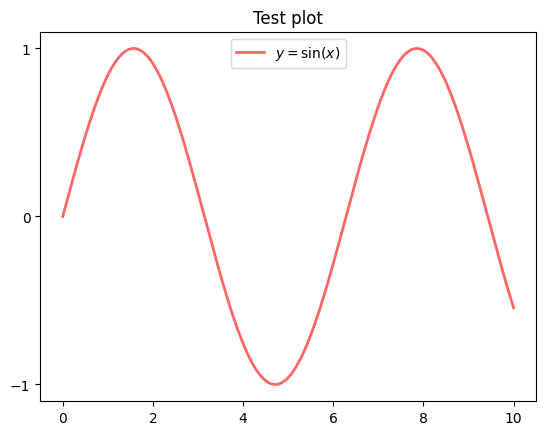

In [7]:
x = np.linspace(0, 10, 200)
y = np.sin(x)

# Configure custom y-ticks and title
fig, ax = plt.subplots()
ax.plot(x, y, 'r-', linewidth=2, label=r'$y=\sin(x)$', alpha=0.6)
ax.legend(loc='upper center')
ax.set_yticks([-1, 0, 1])
ax.set_title('Test plot')
plt.show()


## Example 7: Multiple Plots on One Axis (Section 11.3.1)
Randomly generating three normal densities with different means $\mu$ and standard deviations $\sigma$, plotted on the same axes.

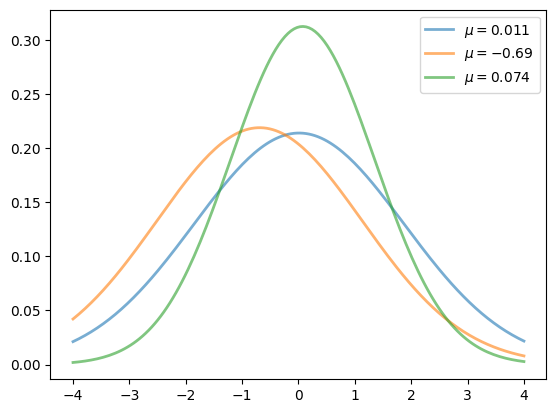

In [8]:
fig, ax = plt.subplots()
x = np.linspace(-4, 4, 150)

# Generate and plot three random normal density curves
for i in range(3):
    m, s = uniform(-1, 1), uniform(1, 2)
    y = norm.pdf(x, loc=m, scale=s)
    current_label = rf'$\mu = {m:.2}$'
    ax.plot(x, y, linewidth=2, alpha=0.6, label=current_label)

ax.legend()
plt.show()


## Example 8: Multiple Subplots (Section 11.3.2)
Generating a 3x2 grid of subplots (6 histograms) sampled from random normal distributions, with individual titles and customized ticks.

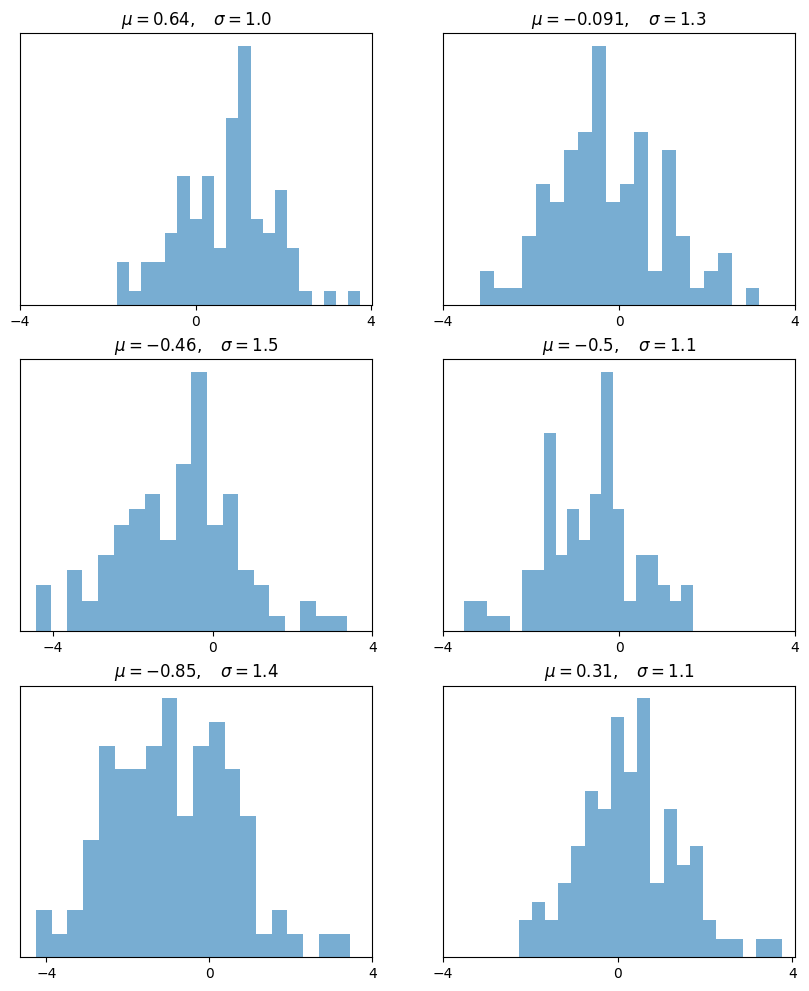

In [9]:
num_rows, num_cols = 3, 2
fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 12))

# Populate each subplot in the grid
for i in range(num_rows):
    for j in range(num_cols):
        m, s = uniform(-1, 1), uniform(1, 2)
        x = norm.rvs(loc=m, scale=s, size=100)
        axes[i, j].hist(x, alpha=0.6, bins=20)
        t = rf'$\mu = {m:.2}, \quad \sigma = {s:.2}$'
        axes[i, j].set(title=t, xticks=[-4, 0, 4], yticks=[])

plt.show()


## Example 9: 3D Plots (Section 11.3.3)
Creating a 3D surface plot using `Axes3D`, `ax.plot_surface`, and the `cm.jet` colormap.

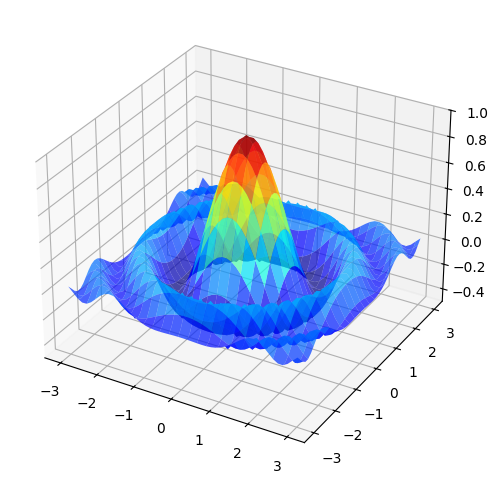

In [10]:
# Define 3D surface mathematical function
def f_3d(x, y):
    return np.cos(x**2 + y**2) / (1 + x**2 + y**2)

# Generate 2D coordinate meshgrid
xgrid = np.linspace(-3, 3, 50)
ygrid = xgrid
x, y = np.meshgrid(xgrid, ygrid)

# Plot 3D surface
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x,
                y,
                f_3d(x, y),
                rstride=2, cstride=2,
                cmap=cm.jet,
                alpha=0.7,
                linewidth=0.25)
ax.set_zlim(-0.5, 1.0)
plt.show()


## Example 10: A Customizing Function (Section 11.3.4)
Defining a reusable custom `subplots()` function that positions the axes through the origin $(0, 0)$, hides the top and right spines, and enables a grid.

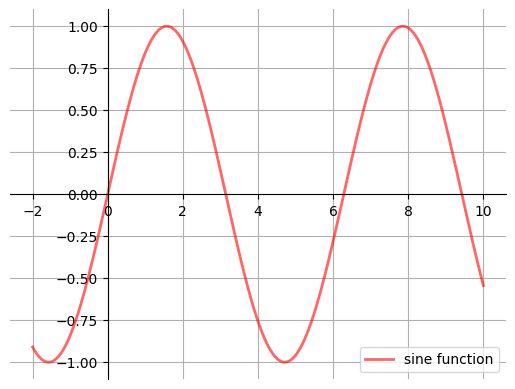

In [11]:
def subplots():
    "Custom subplots with axes through the origin"
    fig, ax = plt.subplots()
    # Set the axes through the origin
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_position('zero')
    for spine in ['right', 'top']:
        ax.spines[spine].set_color('none')
    ax.grid()
    return fig, ax

# Call the local custom version, not plt.subplots()
fig, ax = subplots()
x = np.linspace(-2, 10, 200)
y = np.sin(x)
ax.plot(x, y, 'r-', linewidth=2, label='sine function', alpha=0.6)
ax.legend(loc='lower right')
plt.show()


## Example 11: Style Sheets - Listing Available Styles (Section 11.3.5)
Listing all available built-in style sheets in Matplotlib by printing `plt.style.available`.

In [12]:
# Display available style sheets
print(plt.style.available)


['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


## Example 12: Defining the Style Comparison Function (Section 11.3.5)
Defining a helper function `draw_graphs(style)` that renders 4 subplots (density plot, scatter plot, histogram, and line graph) to evaluate different styles.

In [13]:
def draw_graphs(style='default'):
    # Set the desired style sheet
    plt.style.use(style)
    fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
    x = np.linspace(-13, 13, 150)
    # Set random seed to ensure reproducible plots
    np.random.seed(9)
    for i in range(3):
        # Draw mean and standard deviation from uniform distributions
        m, s = np.random.uniform(-8, 8), np.random.uniform(2, 2.5)
        # 1. Normal density plot
        y = norm.pdf(x, loc=m, scale=s)
        axes[0].plot(x, y, linewidth=3, alpha=0.7)
        # 2. Scatter plot with random X and Y normal values
        rnormX = norm.rvs(loc=m, scale=s, size=150)
        rnormY = norm.rvs(loc=m, scale=s, size=150)
        axes[1].plot(rnormX, rnormY, ls='none', marker='o', alpha=0.7)
        # 3. Histogram with random X values
        axes[2].hist(rnormX, alpha=0.7)
        # 4. Line graph with random Y values
        axes[3].plot(x, rnormY, linewidth=2, alpha=0.7)
    style_name = style.split('-')[0]
    plt.suptitle(f'Style: {style_name}', fontsize=13)
    plt.show()

print("Helper function draw_graphs defined successfully.")


Helper function draw_graphs defined successfully.


## Example 13: Style Sheets - Testing 'seaborn-v0_8' (Section 11.3.5)
Demonstrating plots rendered with the Seaborn visual theme.

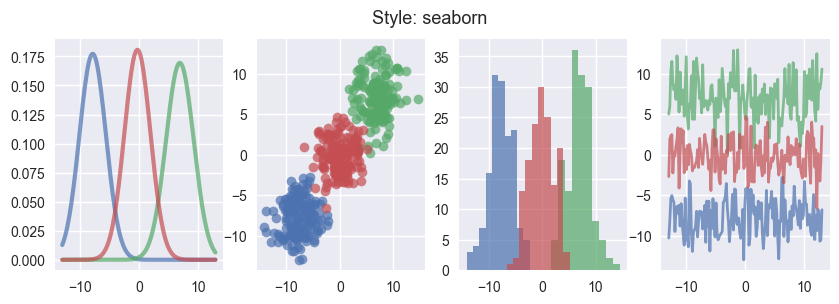

In [14]:
# Render graphs using seaborn style
draw_graphs(style='seaborn-v0_8')


## Example 14: Style Sheets - Testing 'grayscale' (Section 11.3.5)
Demonstrating plots in grayscale (monochrome), suitable for black-and-white academic printing.

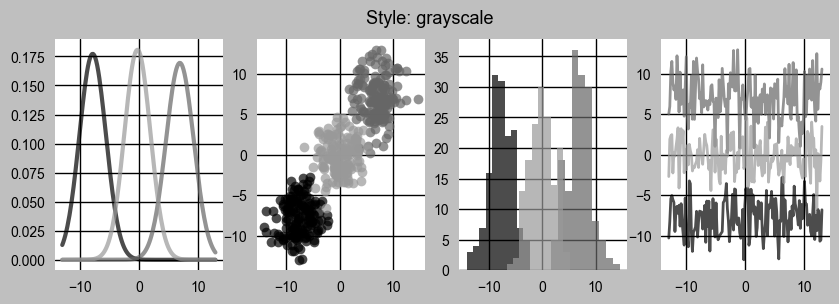

In [15]:
# Render graphs using grayscale style
draw_graphs(style='grayscale')


## Example 15: Style Sheets - Testing 'ggplot' (Section 11.3.5)
Demonstrating plots formatted with the aesthetics of R's popular `ggplot2` library.

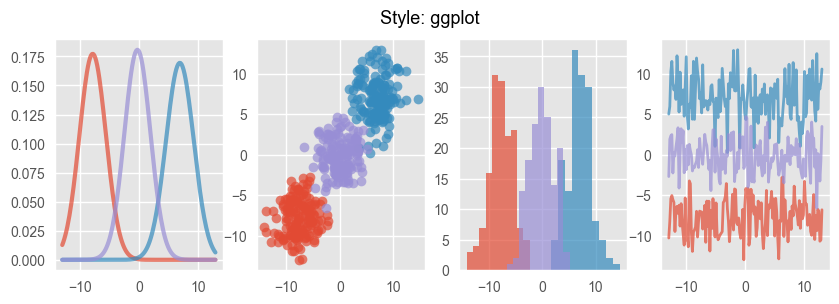

In [16]:
# Render graphs using ggplot style
draw_graphs(style='ggplot')


## Example 16: Style Sheets - Testing 'dark_background' (Section 11.3.5)
Demonstrating plots rendered on an inverted dark background theme.

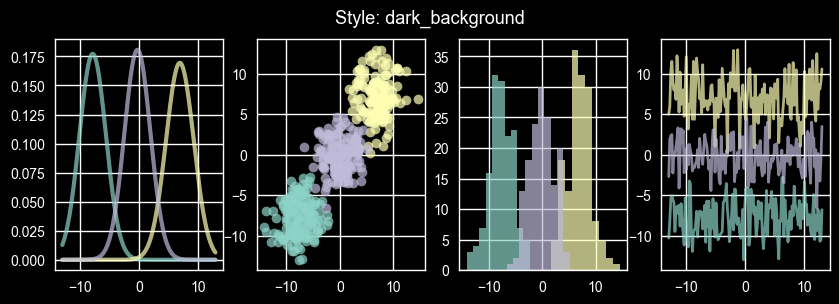

In [17]:
# Render graphs using dark_background style
draw_graphs(style='dark_background')


## Example 17: Customizing rcParams - Inspecting Parameter Keys (Section 11.3.5)
Printing the list of configuration keys available in the dictionary-like variable `plt.rcParams`.

In [18]:
# Print rcParams keys
print(plt.rcParams.keys())


KeysView(RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': True,
          'axes.edgecolor': 'white',
          'axes.facecolor': 'black',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': True,
          'axes.grid.axis': 'both

## Example 18: Customizing rcParams with 'cycler' and Density Lines (Section 11.3.5)
Setting font style to italic, adjusting line width, enabling horizontal grid lines, and defining custom color cycles using `cycler`.

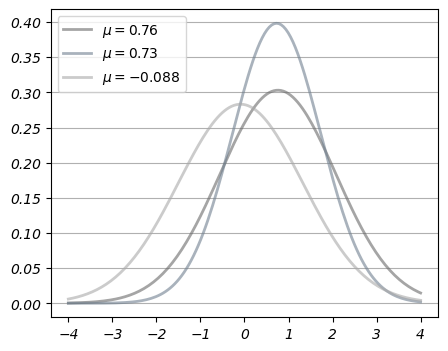

In [19]:
# Reset to default style sheet first
plt.style.use('default')

# Update single parameter values:
# Set font style to italic
plt.rcParams['font.style'] = 'italic'
# Update linewidth
plt.rcParams['lines.linewidth'] = 2

# Update multiple values at once using update():
parameters = {
    # Change default figure size
    'figure.figsize': (5, 4),
    # Add horizontal grid lines
    'axes.grid': True,
    'axes.grid.axis': 'y',
    # Update color cycle for plotted lines
    'axes.prop_cycle': cycler('color', ['dimgray', 'slategrey', 'darkgray'])
}
plt.rcParams.update(parameters)

# Plot overlaid density lines using custom rcParams
fig, ax = plt.subplots()
x = np.linspace(-4, 4, 150)
for i in range(3):
    m, s = uniform(-1, 1), uniform(1, 2)
    y = norm.pdf(x, loc=m, scale=s)
    current_label = rf'$\mu = {m:.2}$'
    ax.plot(x, y, linewidth=2, alpha=0.6, label=current_label)

ax.legend()
plt.show()


## Example 19: Resetting Style and rcParams to Default (Section 11.3.5)
Re-applying the default stylesheet and resetting default figure size to `(10, 6)`.

In [20]:
# Apply the default stylesheet again to revert changes
plt.style.use('default')
# Reset default figure size
plt.rcParams['figure.figsize'] = (10, 6)

print("Style and rcParams successfully reset to default!")


Style and rcParams successfully reset to default!


## Example 20: Exercise 11.5.1 Solution - Plotting a Family of Curves (Section 11.5)
Plotting the function:
$$f(x, \theta) = \cos(\pi \theta x) \exp(-x)$$
over the interval $[0, 5]$ for each $\theta \in \text{np.linspace}(0, 2, 10)$ on the same axes.

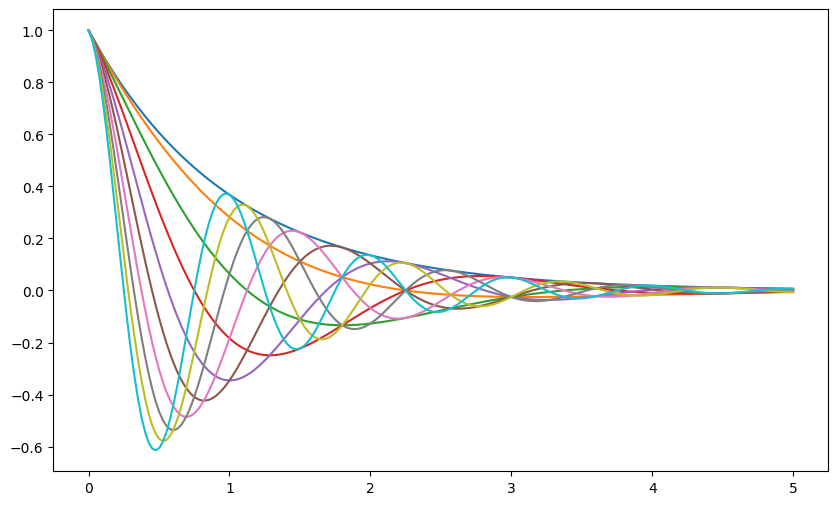

In [21]:
# Define function
def f(x, theta):
    return np.cos(np.pi * theta * x) * np.exp(-x)

# Values of theta parameter and domain interval x
theta_vals = np.linspace(0, 2, 10)
x = np.linspace(0, 5, 200)

# Plot all curves on the same figure
fig, ax = plt.subplots()
for theta in theta_vals:
    ax.plot(x, f(x, theta))

plt.show()
